In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash",
    temperature=0
)

In [4]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')



class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [5]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [6]:
prompt = 'What is the sentiment of the following review - The software is too bad'
structured_model2.invoke(prompt)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


DiagnosisSchema(issue_type='Other', tone='disappointed', urgency='low')

In [7]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [8]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [9]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

In [10]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [11]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [12]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [13]:
graph = StateGraph(ReviewState)

# add nodes
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# add edges with conditions
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

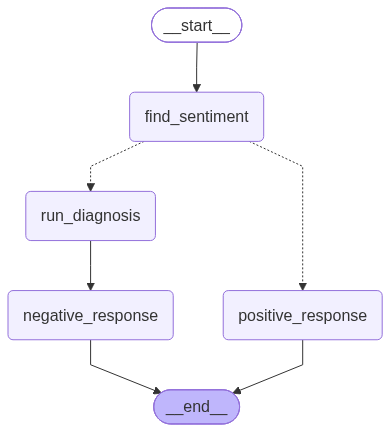

In [14]:
workflow

In [15]:
intial_state={
    'review': "Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!"
}
result = workflow.invoke(intial_state)

In [16]:
result

{'review': 'Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!',
 'sentiment': 'positive',
 'response': [{'type': 'text',
   'text': 'Here is a warm and appreciative response you can use:\n\n***\n\n**Subject: Thank you so much for your wonderful review!**\n\nHi [User Name/there],\n\nThank you so much for taking the time to share such a wonderful review! We are absolutely thrilled to hear that our software has made a positive impact on your workflow and saved you valuable time. Knowing that you appreciate the clean interface and smooth performance is incredibly rewarding for our team. \n\nIf you have a quick moment, we would be so grateful if you could share your feedback directly on our website as well [Insert Link]. Your review helps other teams looking for a reliable tech solution find us, and it inspires us to keep making the software

In [17]:
intial_state={
    'review': "The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement."
}
result = workflow.invoke(intial_state)
result

{'review': 'The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'medium'},
 'response': [{'type': 'text',
   'text': "Subject: Update on your support ticket: We've resolved the issue!\n\nHi [User Name],\n\nI completely understand how frustrating it is when a bug disrupts your workflow, and I want to thank you for your patience while we worked to get this sorted out. I know your time is valuable, and dealing with unexpected technical glitches is never easy. \n\nI’m happy to let you know that our engineering team has successfully identified and fixed the bug you reported. \n\nTo ensure the fix is fully applied on your end, please try the following quick steps:\n1. **Log out** of your account.\n2. **Clear your browser's cache**